In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import cv2
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
df = pd.read_csv('/content/drive/MyDrive/monkeytype/monkeytyping.csv')
df.head()

,participant_id,date,original_filename,trial_number,reaction_time,correct,correct_position,chosen_position,prompt,sample_name,...,file_path,stimuli_quantity,colored,nut_quantity,juice_quantity,datetime,mean_reaction_time,percent_correct,omission_percent,experiment_duration
0,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,1,1029,0,2th,3th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"
1,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,2,579,1,2th,2th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"
2,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,3,688,0,3th,4th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"
3,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,4,578,0,4th,2th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"
4,Jupiter,02.06.2025,02.06.2025 - Jupiter.txt,5,848,1,4th,4th,NaN,NaN,...,/content/drive/MyDrive/Pavlov/Макаки учатся/Ex...,4.0,NaN,1.0,0.0,02.06.2025 11:59:45,980.0,35.0,4.0,"9 min, 35 sec"


In [3]:
df_symbols = df[df['colored'].isna()].copy(deep=True)
df_symbols = df_symbols[df_symbols['file_3_name'].notna()].copy(deep=True)
#df_symbols.info()
image_filepath_main = '/content/drive/MyDrive/monkeytype/emnist_rare_ESRGAN_improved/'
file_cols_name = ['file_1_name', 'file_2_name', 'file_3_name', 'file_4_name']
for f in file_cols_name:
  df_symbols[f] = df_symbols[f].astype(str)
  for index, row in df_symbols.iterrows():
    df_symbols.loc[index, f] = df_symbols.loc[index, f][0] + '/'+df_symbols.loc[index, f][2:] + '_out.png'
print(df_symbols[file_cols_name[0]])

0       y/00902_out.png
1       s/00320_out.png
2       c/01270_out.png
3       f/00745_out.png
4       s/01180_out.png
             ...       
6154    f/01252_out.png
6155    m/01187_out.png
6156    m/00439_out.png
6157    m/00413_out.png
6158    c/00117_out.png
Name: file_1_name, Length: 5339, dtype: object


In [4]:
df_files = df_symbols[file_cols_name].copy(deep = True)
df_files.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5339 entries, 0 to 6158
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   file_1_name  5339 non-null   object
 1   file_2_name  5339 non-null   object
 2   file_3_name  5339 non-null   object
 3   file_4_name  5339 non-null   object
dtypes: object(4)
memory usage: 337.6+ KB


In [5]:
symbols_list = ['m', 'c', 's', 'y', 'f', 'j']

In [6]:
new_file_cols = ['file_1_symb', 'file_2_symb', 'file_3_symb', 'file_4_symb']
for index, row in df_files.iterrows():
  for f, fs in zip(file_cols_name, new_file_cols):
    df_files.loc[index, fs] = df_files.loc[index, f][0]
df_files.head()

,file_1_name,file_2_name,file_3_name,file_4_name,file_1_symb,file_2_symb,file_3_symb,file_4_symb
0,y/00902_out.png,c/00891_out.png,f/01542_out.png,m/00280_out.png,y,c,f,m
1,s/00320_out.png,f/01788_out.png,m/01766_out.png,j/01080_out.png,s,f,m,j
2,c/01270_out.png,y/00523_out.png,j/01415_out.png,m/00902_out.png,c,y,j,m
3,f/00745_out.png,s/00125_out.png,m/01681_out.png,c/00697_out.png,f,s,m,c
4,s/01180_out.png,y/00443_out.png,j/01331_out.png,m/00367_out.png,s,y,j,m


In [7]:
for index, row in df_files.iterrows():
  for f in file_cols_name:
    df_files.loc[index, f] = image_filepath_main + df_files.loc[index, f]
df_files.head()

,file_1_name,file_2_name,file_3_name,file_4_name,file_1_symb,file_2_symb,file_3_symb,file_4_symb
0,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,y,c,f,m
1,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,s,f,m,j
2,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,c,y,j,m
3,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,f,s,m,c
4,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,/content/drive/MyDrive/monkeytype/emnist_rare_...,s,y,j,m


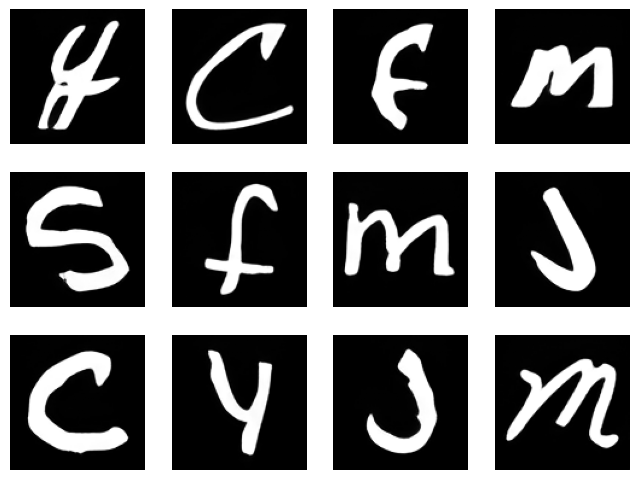

In [15]:
img_list=[]
for index, row in df_files.iterrows():
  if index<3:
    for f, fs in zip(file_cols_name, new_file_cols):
      img = cv2.imread(df_files.loc[index, f], cv2.IMREAD_GRAYSCALE)
      img_list.append(img)
  else:
    break

fig = plt.figure(figsize=(8, 6))
columns = 4
rows = 3
for i in range(0, columns*rows):
    img = img_list[i]
    fig.add_subplot(rows, columns, i+1)
    plt.imshow(img, cmap='gray')
    plt.axis('off')
plt.show()